<a href="https://colab.research.google.com/github/carolinaoj/Desafio-Alura/blob/main/ensayoAlura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Desafío Alura Store: Análisis de Eficiencia para el Sr. Juan

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
# Nota: Respetamos el espacio en el nombre del archivo 'tienda_1 .csv'
t1 = pd.read_csv('/content/Ensayo/tienda_1 .csv')
t2 = pd.read_csv('/content/Ensayo/tienda_2.csv')
t3 = pd.read_csv('/content/Ensayo/tienda_3.csv')
t4 = pd.read_csv('/content/Ensayo/tienda_4.csv')

# Agregar columna identificadora
t1['Tienda'], t2['Tienda'], t3['Tienda'], t4['Tienda'] = 'Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'

# Unificar todo en un solo DataFrame
df = pd.concat([t1, t2, t3, t4], ignore_index=True)

print("Datos cargados exitosamente. Total de registros:", len(df))
df.head()

Datos cargados exitosamente. Total de registros: 9435


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Tienda
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175,Tienda 1
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359,Tienda 1
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444,Tienda 1
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250,Tienda 1
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359,Tienda 1


In [4]:
# Agrupar datos por tienda para el análisis
resumen = df.groupby('Tienda').agg({
    'Precio': 'sum',
    'Calificación': 'mean',
    'Costo de envío': 'mean'
}).reset_index()

resumen.columns = ['Tienda', 'Ingresos_Totales', 'Review_Promedio', 'Envio_Promedio']
resumen

,Tienda,Ingresos_Totales,Review_Promedio,Envio_Promedio
0,Tienda 1,1.150880e+09,3.976685,26018.609580
1,Tienda 2,1.116344e+09,4.037304,25216.235693
2,Tienda 3,1.098020e+09,4.048326,24805.680373
3,Tienda 4,1.038376e+09,3.995759,23459.457167


/tmp/ipykernel_262/1421044731.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen, x='Tienda', y='Ingresos_Totales', palette='viridis')


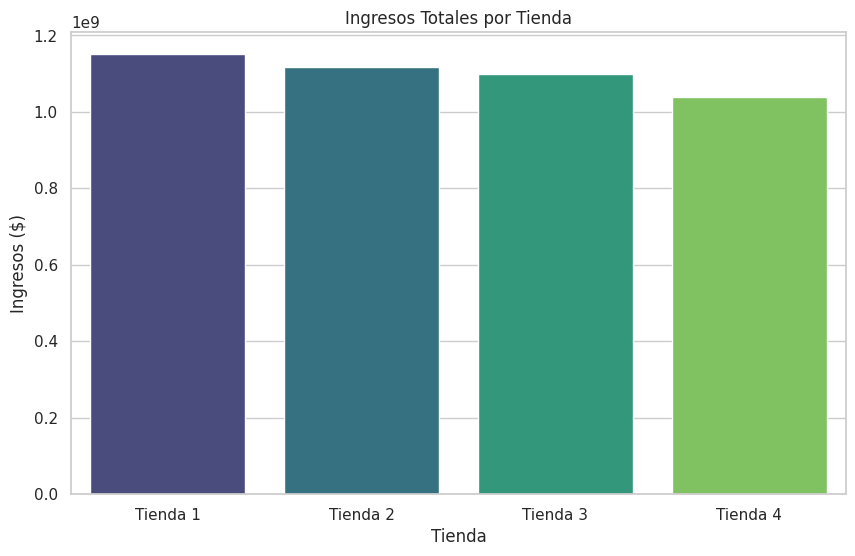

In [7]:
# 1. Gráfico de Barras: Ingresos Totales
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(data=resumen, x='Tienda', y='Ingresos_Totales', palette='viridis')
plt.title('Ingresos Totales por Tienda')
plt.ylabel('Ingresos ($)')
plt.show()

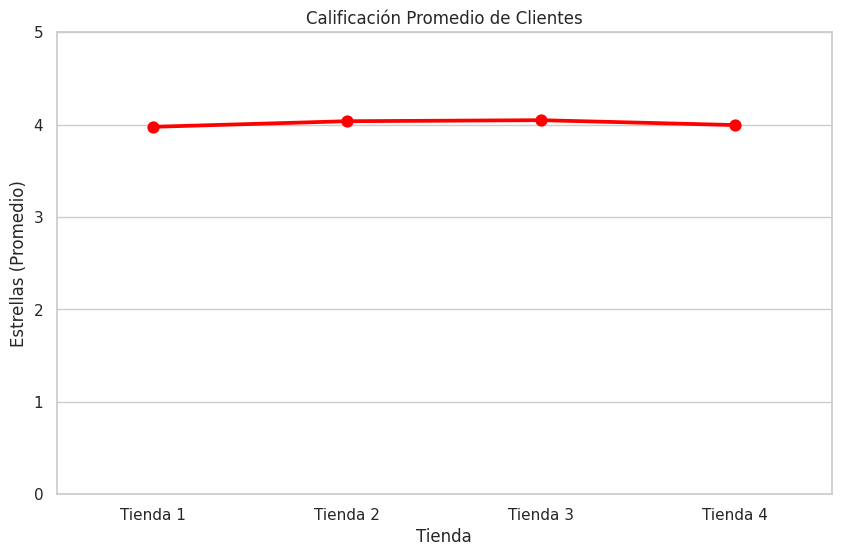

In [8]:
# 2. Gráfico de Puntos: Calificaciones Promedio
plt.figure(figsize=(10, 6))
sns.pointplot(data=resumen, x='Tienda', y='Review_Promedio', color='red')
plt.title('Calificación Promedio de Clientes')
plt.ylabel('Estrellas (Promedio)')
plt.ylim(0, 5) # Para ver la escala real de 0 a 5
plt.show()

/tmp/ipykernel_262/1817540383.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Tienda', y='Costo de envío', palette='Pastel1')


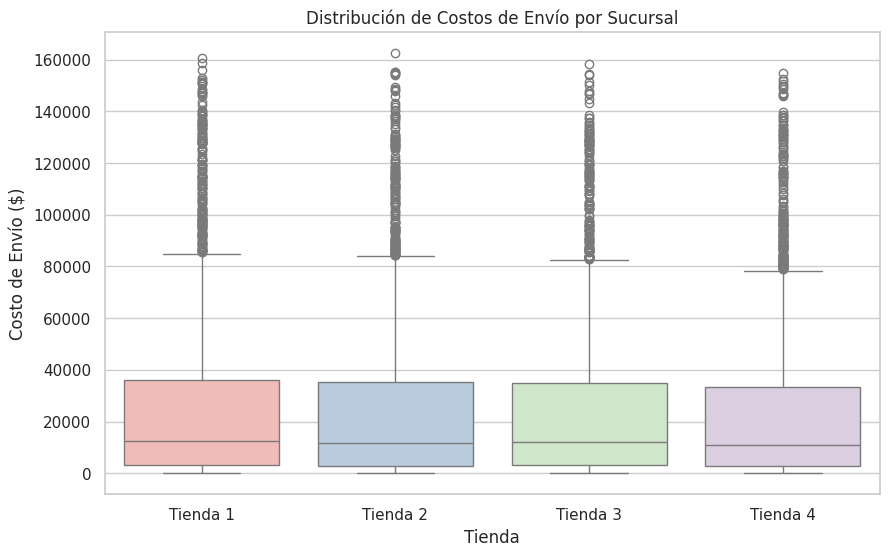

In [9]:
# 3. Gráfico de Caja: Costos de Envío
# Nota: Aquí usamos 'df' (el dataframe original con todos los datos)
# para ver la dispersión completa de los costos.
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Tienda', y='Costo de envío', palette='Pastel1')
plt.title('Distribución de Costos de Envío por Sucursal')
plt.ylabel('Costo de Envío ($)')
plt.show()

Hallazgos Principales:

Volumen de Ventas: La Tienda 4

registra el desempeño financiero más bajo, con ingresos totales de $1,038,376,000, quedando por debajo de la Tienda 1 y la Tienda 2.
La Tienda 1 tiene el promedio de reseñas más bajo (3.97), lo cual indica problemas potenciales de servicio o calidad. Sin embargo, la Tienda 4 tampoco destaca, manteniéndose en un rango bajo de 3.99.
La Tienda 1 es la que genera mayores costos de envío promedio, lo que reduce su margen de beneficio neto a pesar de vender más que la Tienda 4.

Tienda Seleccionada para la Venta
Basándonos en los datos, la recomendación técnica es vender la Tienda 4.

La elección de vender la Tienda 4 se fundamenta en los siguientes puntos:
Al ser la tienda con menos ingresos, su salida de la cadena representa el menor sacrificio de flujo de caja para la empresa.
A pesar de tener costos de envío más bajos que la Tienda 1, no ha logrado convertir esa ventaja competitiva en un mayor volumen de ventas ni en una fidelización de clientes superior.
Liberar el capital invertido en la Tienda 4 permitirá al Sr. Juan financiar su nuevo emprendimiento con recursos provenientes de la unidad menos productiva del grupo.